In [21]:
import IPython
print ("IPython version: "+IPython.__version__+" (need at least 1.0)")
# Numpy is a library for working with Arrays
import numpy as np
print ("Numpy version: "+np.__version__+" (need at least 1.7.1)" )
# SciPy implements many different numerical algorithms
import scipy as sp
print ("SciPy version:"+sp.__version__+" (need at least 0.12.0)")
# Pandas makes working with data tables easier
import pandas as pd
print ("Pandas version:"+pd.__version__+" (need at least 0.11.0)")
# Module for plotting
import matplotlib
print ("Mapltolib version:"+matplotlib.__version__+" (need at least 1.2.1)")
# Scikit Learn implements several Machine Learning algorithms
import sklearn
print ("Scikit-Learn version:"+ sklearn.__version__+" (need at least 0.13.1)")

IPython version: 9.15.0 (need at least 1.0)
Numpy version: 2.4.6 (need at least 1.7.1)
SciPy version:1.18.0 (need at least 0.12.0)
Pandas version:3.0.5 (need at least 0.11.0)
Mapltolib version:3.11.1 (need at least 1.2.1)
Scikit-Learn version:1.9.0 (need at least 0.13.1)


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [23]:
flights_df= pd.read_csv('flights(in).csv')

In [24]:
flights_df.head()

,Unnamed: 0,year,month,day,dep_time,dep_delay,arr_time,arr_delay,carrier,tailnum,flight,origin,dest,air_time,distance,hour,minute
0,1,2013,1,1,517.0,2.0,830.0,11.0,UA,N14228,1545,EWR,IAH,227.0,1400,5.0,17.0
1,2,2013,1,1,533.0,4.0,850.0,20.0,UA,N24211,1714,LGA,IAH,227.0,1416,5.0,33.0
2,3,2013,1,1,542.0,2.0,923.0,33.0,AA,N619AA,1141,JFK,MIA,160.0,1089,5.0,42.0
3,4,2013,1,1,544.0,-1.0,1004.0,-18.0,B6,N804JB,725,JFK,BQN,183.0,1576,5.0,44.0
4,5,2013,1,1,554.0,-6.0,812.0,-25.0,DL,N668DN,461,LGA,ATL,116.0,762,5.0,54.0


In [25]:
print(flights_df.shape)
print(flights_df.columns)
print(flights_df.dtypes)

(336776, 17)
Index(['Unnamed: 0', 'year', 'month', 'day', 'dep_time', 'dep_delay',
       'arr_time', 'arr_delay', 'carrier', 'tailnum', 'flight', 'origin',
       'dest', 'air_time', 'distance', 'hour', 'minute'],
      dtype='str')
Unnamed: 0      int64
year            int64
month           int64
day             int64
dep_time      float64
dep_delay     float64
arr_time      float64
arr_delay     float64
carrier           str
tailnum           str
flight          int64
origin            str
dest              str
air_time      float64
distance        int64
hour          float64
minute        float64
dtype: object


In [26]:
flights_df.tail()

,Unnamed: 0,year,month,day,dep_time,dep_delay,arr_time,arr_delay,carrier,tailnum,flight,origin,dest,air_time,distance,hour,minute
336771,336772,2013,9,30,NaN,NaN,NaN,NaN,9E,NaN,3393,JFK,DCA,NaN,213,NaN,NaN
336772,336773,2013,9,30,NaN,NaN,NaN,NaN,9E,NaN,3525,LGA,SYR,NaN,198,NaN,NaN
336773,336774,2013,9,30,NaN,NaN,NaN,NaN,MQ,N535MQ,3461,LGA,BNA,NaN,764,NaN,NaN
336774,336775,2013,9,30,NaN,NaN,NaN,NaN,MQ,N511MQ,3572,LGA,CLE,NaN,419,NaN,NaN
336775,336776,2013,9,30,NaN,NaN,NaN,NaN,MQ,N839MQ,3531,LGA,RDU,NaN,431,NaN,NaN


In [27]:
# Your code here
dest_seattle = flights_df['dest']=='SEA'
len(flights_df[dest_seattle])


3923

In [28]:
flights_seattle_df = flights_df[dest_seattle]
len(flights_seattle_df['carrier'].unique())


5

In [29]:
flights_seattle_df['tailnum'].nunique()


935

In [30]:
flights_seattle_df['tailnum'].unique()


<ArrowStringArray>
['N594AS', 'N3760C', 'N45440', 'N37464', 'N503JB', 'N77296', 'N553AS',
 'N3ETAA', 'N3772H', 'N76523',
 ...
 'N3BMAA', 'N3BGAA', 'N3KEAA', 'N3BLAA', 'N408UA', 'N833UA', 'N557AS',
 'N483UA', 'N814UA', 'N561JB']
Length: 936, dtype: str

In [31]:
flights_seattle_df['arr_delay'].mean()

np.float64(-1.0990990990990992)

In [32]:
print(flights_seattle_df.groupby('origin').size()/flights_seattle_df['flight'].count())


origin
EWR    0.466735
JFK    0.533265
dtype: float64


In [33]:
flights_grp_dd_df = flights_df.groupby(['month','day'],as_index = False).agg({'dep_delay':'mean'})
max_dep_delay = flights_grp_dd_df['dep_delay'].max()
print(flights_grp_dd_df[flights_grp_dd_df['dep_delay']== max_dep_delay])
flights_grp_ad_df = flights_df.groupby(['month','day'],as_index = False).agg({'arr_delay':'mean'})
max_arr_delay = flights_grp_ad_df['arr_delay'].max()
print(flights_grp_ad_df[flights_grp_ad_df['arr_delay']== max_arr_delay])


    month  day  dep_delay
66      3    8  83.536921
    month  day  arr_delay
66      3    8  85.862155


In [34]:
#Worst day is the day with maximum number of delayed flights(flights with positive departure delay)
flights_grp_dd_df = flights_df[flights_df['dep_delay']>0].groupby(['month','day'],as_index = False).agg({'flight':'count'})
#print(flights_grp_dd_df)
max_delayed_flights = flights_grp_dd_df['flight'].max()
print(flights_grp_dd_df[flights_grp_dd_df['flight'] == max_delayed_flights])

     month  day  flight
356     12   23     674


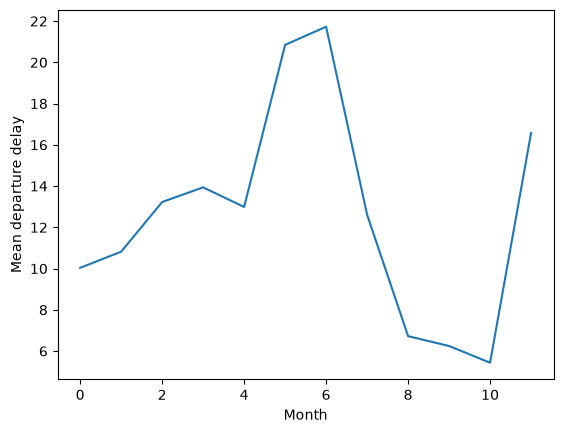

In [35]:
delay_mon_grp = flights_df.groupby(['month'],as_index = False).agg({'dep_delay':'mean'})
delay_mon_grp['dep_delay'].plot()
plt.xlabel('Month')
plt.ylabel('Mean departure delay')
plt.show()

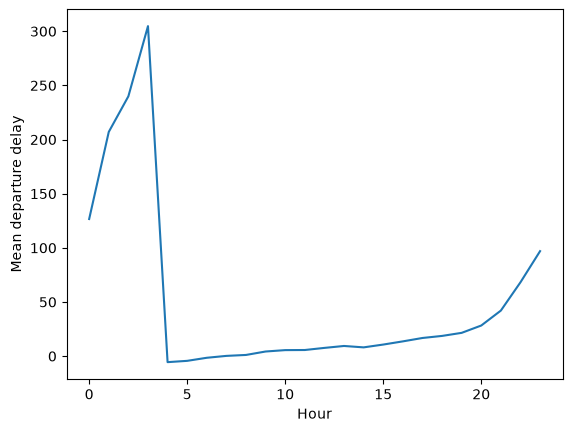

In [36]:
#flights_df = pd.read_csv('flights.csv')
flights_df.loc[flights_df.hour == 24 ,'hour'] = 0
delay_grp = flights_df.groupby(['hour'],as_index = False).agg({'dep_delay':'mean'})
delay_grp['dep_delay'].plot()
plt.xlabel('Hour')
plt.ylabel('Mean departure delay')
plt.show()
#flights_df['dep_delay'].hist(by=flights_df['hour'])


In [37]:
# Fastest flight = Flight details with the max speed
# Speed = distance/time = distance in miles/airtime in hr = distance in miles/(airtime in min/60)
flights_df['speed'] = flights_df.distance/(flights_df.air_time/60)
max_speed = max(flights_df['speed'])
flights_df[flights_df['speed']== max_speed]


,Unnamed: 0,year,month,day,dep_time,dep_delay,arr_time,arr_delay,carrier,tailnum,flight,origin,dest,air_time,distance,hour,minute,speed
216447,216448,2013,5,25,1709.0,9.0,1923.0,-14.0,DL,N666DN,1499,LGA,ATL,65.0,762,17.0,9.0,703.384615


In [38]:
#To find the carrier+flight+dest combination which flies every day of the year. Also find the destination of the flight.
flights_df['unique_day'] = pd.factorize(flights_df.month+flights_df.day)[0]
flights_count_df = flights_df.groupby(['flight','carrier','dest'],as_index = False).agg({'unique_day':'count'})
print(len(flights_count_df[flights_count_df['unique_day']>=365]))
print(flights_count_df[flights_count_df['unique_day']>=365].dest.unique())


18
<ArrowStringArray>
['HNL', 'SFO', 'LAX', 'CLT', 'LAS', 'BUR', 'FLL', 'SRQ', 'SJU', 'MIA', 'MCO',
 'TPA', 'IAD']
Length: 13, dtype: str


  carrier  dep_delay
0      AA  10.041551
1      AS   5.804775
2      B6  11.592593
3      DL   7.391376
4      UA  17.315647


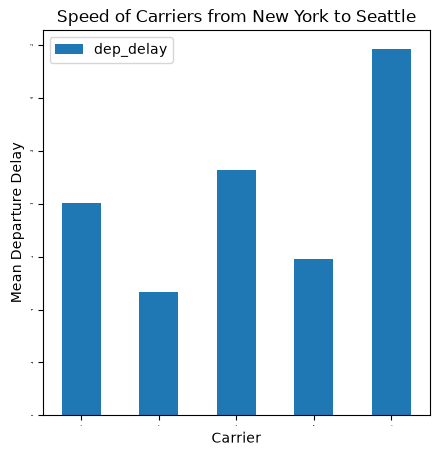

  carrier  arr_delay
0      AA  -1.475000
1      AS  -9.930889
2      B6   7.721248
3      DL  -5.886023
4      UA   5.827430


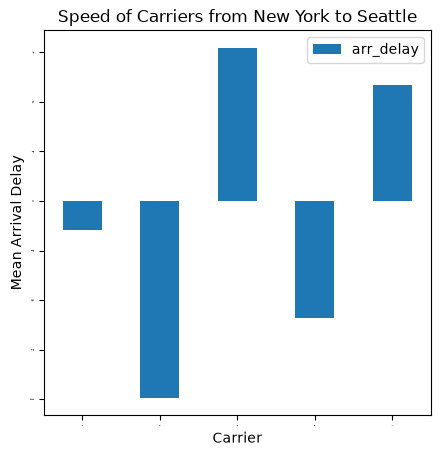

In [39]:
flights_speed_dep_df = flights_seattle_df.groupby(['carrier'],as_index = False).agg({'dep_delay':'mean'})
print(flights_speed_dep_df)
flights_speed_dep_df.plot(kind='bar', title ="Speed of Carriers from New York to Seattle",figsize=(5,5),legend=True, fontsize=1)
plt.xlabel('Carrier')
plt.ylabel('Mean Departure Delay')
plt.show()
plt.close()
flights_speed_arr_df = flights_seattle_df.groupby(['carrier'],as_index = False).agg({'arr_delay':'mean'})
print(flights_speed_arr_df)
flights_speed_arr_df.plot(kind='bar', title ="Speed of Carriers from New York to Seattle",figsize=(5,5),legend=True, fontsize=1)
plt.xlabel('Carrier')
plt.ylabel('Mean Arrival Delay')
plt.show()
plt.close()

In [40]:
weather_df = pd.read_csv('weather(in).csv')
weather_df.head()
combined_df = pd.merge(flights_df,weather_df, how = 'left', on = ['origin','year','month','day','hour'])
print(combined_df.head())
combined_df = combined_df[['month','day','dep_delay','temp','humid','visib','dewp','wind_dir','wind_speed','wind_gust','precip', 'pressure']]
wea_temp_day_df = combined_df.groupby(['month','day'],as_index = False).agg({'dep_delay':'mean','temp':'mean','humid':'mean', 'visib':'mean', 'dewp':'mean', 'wind_dir':'mean', 'wind_speed':'mean', 'wind_gust':'mean', 'precip':'mean', 'pressure':'mean'})
print(wea_temp_day_df.columns)

   Unnamed: 0_x  year  month  day  dep_time  dep_delay  arr_time  arr_delay  \
0             1  2013      1    1     517.0        2.0     830.0       11.0   
1             2  2013      1    1     533.0        4.0     850.0       20.0   
2             3  2013      1    1     542.0        2.0     923.0       33.0   
3             4  2013      1    1     544.0       -1.0    1004.0      -18.0   
4             5  2013      1    1     554.0       -6.0     812.0      -25.0   

  carrier tailnum  ...  Unnamed: 0_y temp dewp  humid  wind_dir  wind_speed  \
0      UA  N14228  ...           NaN  NaN  NaN    NaN       NaN         NaN   
1      UA  N24211  ...           NaN  NaN  NaN    NaN       NaN         NaN   
2      AA  N619AA  ...           NaN  NaN  NaN    NaN       NaN         NaN   
3      B6  N804JB  ...           NaN  NaN  NaN    NaN       NaN         NaN   
4      DL  N668DN  ...           NaN  NaN  NaN    NaN       NaN         NaN   

   wind_gust  precip  pressure  visib  
0        N

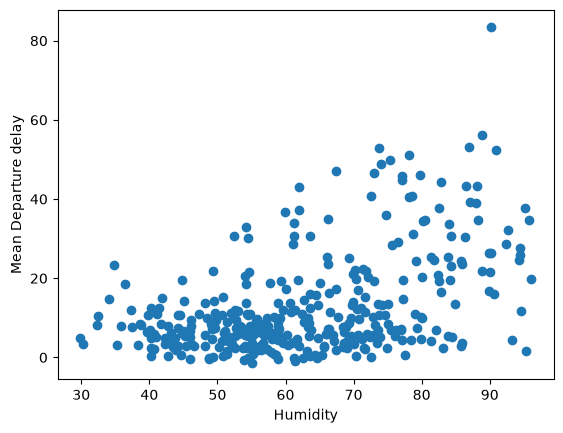

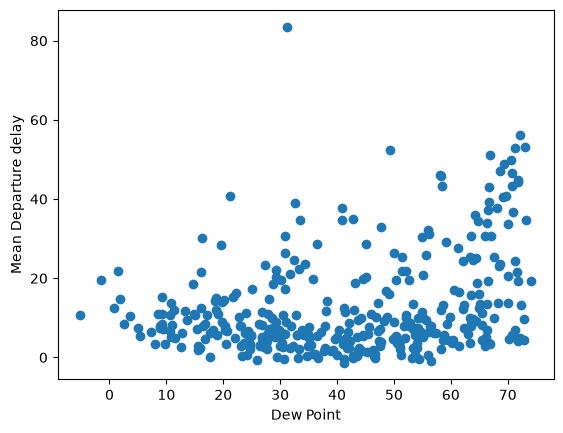

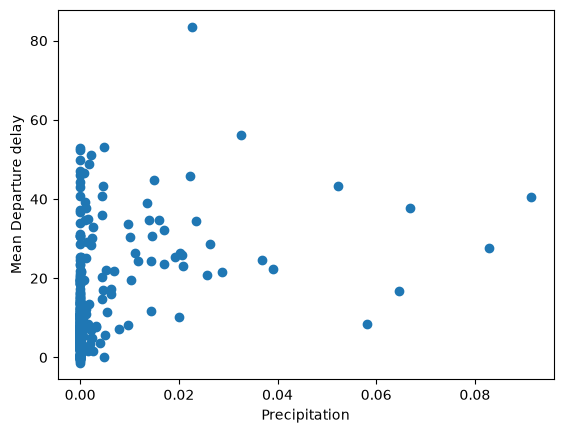

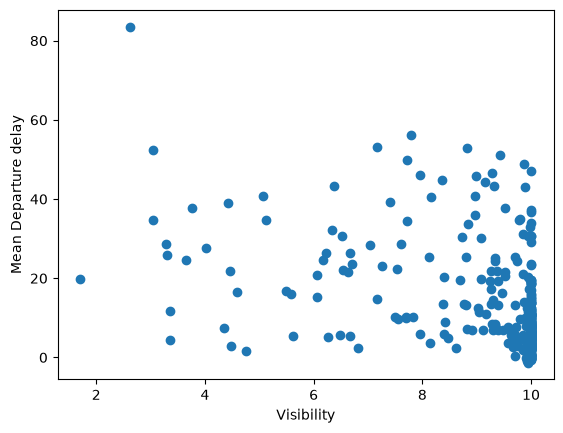

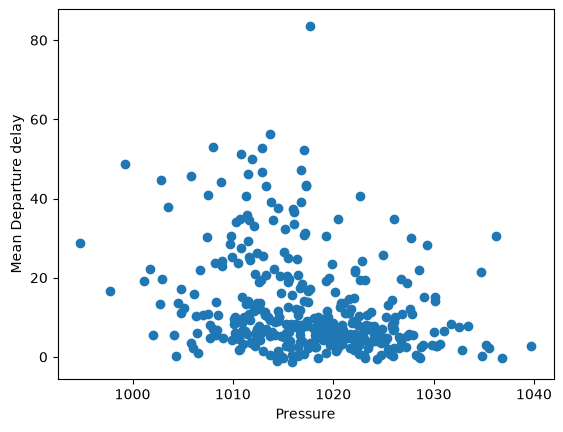

In [41]:
plt.scatter(wea_temp_day_df['humid'], wea_temp_day_df['dep_delay'])
plt.xlabel('Humidity')
plt.ylabel('Mean Departure delay')
plt.show()
plt.close()

plt.scatter(wea_temp_day_df['dewp'], wea_temp_day_df['dep_delay'])
plt.xlabel('Dew Point')
plt.ylabel('Mean Departure delay')
plt.show()
plt.close()

plt.scatter(wea_temp_day_df['precip'], wea_temp_day_df['dep_delay'])
plt.xlabel('Precipitation')
plt.ylabel('Mean Departure delay')
plt.show()
plt.close()

plt.scatter(wea_temp_day_df['visib'], wea_temp_day_df['dep_delay'])
plt.xlabel('Visibility')
plt.ylabel('Mean Departure delay')
plt.show()
plt.close()

plt.scatter(wea_temp_day_df['pressure'], wea_temp_day_df['dep_delay'])
plt.xlabel('Pressure')
plt.ylabel('Mean Departure delay')
plt.show()
plt.close()